# How are in-demand skills trending for Data Engineers?

## Methodology

1. Filter for U.S. Data Engineer roles
2. Aggregate skill counts by month
3. Rank the most requested skills overall
4. Re-analyze skill demand as a percentage of total monthly jobs
5. Plot monthly skill demand trends

In [2]:
# =====================================
# Import, load, clean, and filter data
# =====================================

import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Load dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Convert posting date into datetime format
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Convert skill strings into real Python lists
df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

# Keep only U.S. Data Engineer jobs
df_DE_US = df[
    (df["job_country"] == "United States") &
    (df["job_title_short"] == "Data Engineer")
].copy()

# Create month number (1 = Jan, 12 = Dec)
df_DE_US["job_posted_month_no"] = df_DE_US["job_posted_date"].dt.month

df_DE_US.head()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",7
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '...",11
11,Data Engineer,Data Engineer,"Colorado Springs, CO (+3 others)",via The Muse,Full-time,False,"Texas, United States",2023-11-03 13:06:51,False,True,United States,NaN,NaN,NaN,Philips,"[python, qlik]","{'analyst_tools': ['qlik'], 'programming': ['p...",11
26,Data Engineer,Data Engineer,United States,via LinkedIn,Full-time,False,Georgia,2023-09-15 13:56:18,True,False,United States,NaN,NaN,NaN,Infinite Computer Solutions,NaN,NaN,9
27,Data Engineer,"Principal Data Engineer (Lead), Knowledge Grap...","San Francisco, CA",via LinkedIn,Full-time,False,Georgia,2023-02-18 13:31:24,False,False,United States,NaN,NaN,NaN,Altos Labs,"[python, r, java]","{'programming': ['python', 'r', 'java']}",2


In [3]:
# =====================================
# Build monthly skill-count pivot table
# =====================================

# Split each skill list into separate rows
# Example: ['python', 'sql'] becomes two rows
df_DE_US_explode = df_DE_US.explode("job_skills")

# Create a pivot table:
# rows    = month number
# columns = individual skills
# values  = number of job postings mentioning each skill
df_DE_US_pivot = df_DE_US_explode.pivot_table(
    index="job_posted_month_no",
    columns="job_skills",
    aggfunc="size",
    fill_value=0
)

# Add a temporary Total row
# This sums how often each skill appeared across all months
df_DE_US_pivot.loc["Total"] = df_DE_US_pivot.sum()

# Sort skills from most demanded overall to least demanded
df_DE_US_pivot = df_DE_US_pivot[
    df_DE_US_pivot.loc["Total"]
    .sort_values(ascending=False)
    .index
]

# Remove the temporary Total row after using it for sorting
df_DE_US_pivot = df_DE_US_pivot.drop("Total")

# Display resulting monthly skill table
df_DE_US_pivot

job_skills,sql,python,aws,azure,spark,java,snowflake,hadoop,kafka,scala,...,kali,powerbi,mlpack,qt,fastify,workfront,wrike,xamarin,sqlserver,svelte
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,1826,1745,1119,841,916,695,592,515,547,517,...,0,0,0,0,0,0,0,0,0,0
2,2109,2043,1415,965,1063,829,763,645,647,597,...,0,0,0,0,0,0,0,0,0,0
3,2204,2126,1472,1023,1038,791,704,640,605,587,...,0,0,0,0,0,0,0,0,0,0
4,1914,1868,1222,937,878,682,676,498,514,534,...,0,0,0,0,0,0,0,0,0,0
5,2077,2023,1252,990,952,730,681,529,491,509,...,0,0,0,0,0,0,0,1,0,0
6,2048,1882,1260,947,955,686,668,516,495,459,...,2,0,0,0,0,0,0,0,0,0
7,1789,1689,1166,794,821,615,624,483,448,461,...,0,0,0,1,0,1,0,0,0,0
8,2246,2155,1388,1003,1006,754,749,594,565,557,...,0,0,0,0,0,0,0,0,1,1
9,2090,1934,1267,960,941,671,700,479,500,483,...,0,1,0,0,0,0,0,0,0,0


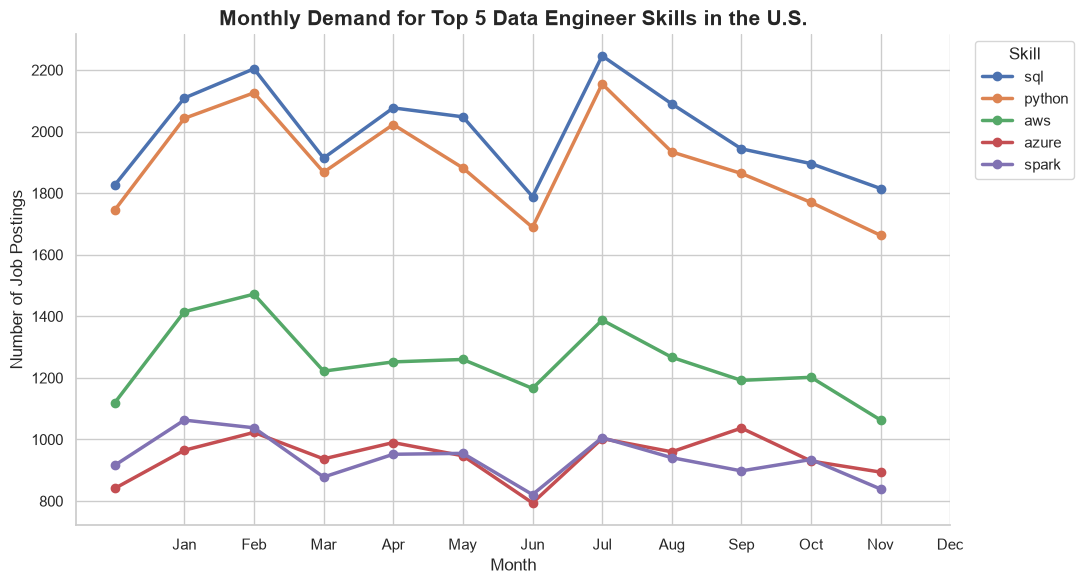

In [6]:
# =====================================
# Plot top 5 Data Engineer skill trends
# =====================================

# Keep only the top 5 skills
# The pivot table is already sorted from most demanded to least demanded
top_5_skills = df_DE_US_pivot.iloc[:, :5]

# Create a clean Seaborn-style figure
sns.set_theme(style="whitegrid")

ax = top_5_skills.plot(
    kind="line",
    figsize=(11, 6),
    linewidth=2.5,
    marker="o"
)

# Add chart title and labels
plt.title(
    "Monthly Demand for Top 5 Data Engineer Skills in the U.S.",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Job Postings")

# Replace month numbers with month names
plt.xticks(
    ticks=range(1, 13),
    labels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
    ]
)

# Give the legend a clearer title
plt.legend(
    title="Skill",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Remove unnecessary chart borders
sns.despine()

# Prevent title / labels / legend from overlapping
plt.tight_layout()

plt.show()